# Pha 1 — Business & Data Understanding: Telco Customer Churn

Notebook này chỉ bao phủ **Pha 1** của CRISP-ML(Q): định nghĩa bài toán, EDA, và data hygiene diagnosis.
Quyết định business (cost matrix, primary metric) đã chốt tại `docs/docs.md`, không lặp lại chi tiết ở đây.

Data cleaning logic được implement 1 lần tại `src/data/loader.py` (dùng chung cho mọi task trên bộ dữ liệu này,
kể cả các task tương lai ngoài classification) — notebook này gọi lại chứ không tự viết logic riêng.

**Không import model/sklearn ở đây** — phần modeling thuộc `02_data_preparation.ipynb` / `03_modeling.ipynb`.


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# notebooks/churn_classification/ -> project root
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import clean, load_raw


## 1. Load raw data & diagnose hidden issues

Đọc dữ liệu **hoàn toàn nguyên bản**, chưa qua bất kỳ fix nào, để tự tay xác nhận các vấn đề data hygiene
trước khi tin tưởng vào `clean()`.


In [2]:
df_raw = load_raw()
print(f"Shape: {df_raw.shape}")
df_raw.info()


Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

`TotalCharges` được đọc là `object` dù nhìn bằng mắt giống cột số — dấu hiệu kinh điển của "kiểu dữ liệu ẩn"
(số bị lưu dưới dạng chuỗi, thường do khoảng trắng hoặc ký tự không in được). Xác nhận trực tiếp:


In [3]:
bad_total_charges = df_raw[pd.to_numeric(df_raw["TotalCharges"], errors="coerce").isna()]
print(f"{len(bad_total_charges)} dong co TotalCharges khong parse duoc thanh so")
bad_total_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]


11 dong co TotalCharges khong parse duoc thanh so


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [4]:
assert (bad_total_charges["tenure"] == 0).all(), "Co dong loi TotalCharges nhung tenure != 0"
print(
    "Xac nhan: 100% cac dong loi TotalCharges trung voi tenure == 0 "
    "(khach hang moi, chua qua billing cycle dau tien) -> day la artefact nghiep vu, "
    "khong phai missing ngau nhien. Khong nen impute, nen loai khoi tap train (xem clean())."
)


Xac nhan: 100% cac dong loi TotalCharges trung voi tenure == 0 (khach hang moi, chua qua billing cycle dau tien) -> day la artefact nghiep vu, khong phai missing ngau nhien. Khong nen impute, nen loai khoi tap train (xem clean()).


## 2. Missing values (raw)

Kiểm tra thêm bằng `isnull().sum()` chuẩn để không bỏ sót cột khác — và để minh họa một cái bẫy: nếu chỉ
chạy `isnull().sum()` trên raw data mà không ép kiểu `TotalCharges` trước, ta **sẽ không thấy** vấn đề ở
trên vì whitespace không được pandas coi là `NaN`.


In [5]:
print("isnull().sum() tren raw (chua ep kieu TotalCharges):")
print(df_raw.isnull().sum())


isnull().sum() tren raw (chua ep kieu TotalCharges):
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
n_hidden_missing = pd.to_numeric(df_raw["TotalCharges"], errors="coerce").isna().sum()
print(f"Sau khi ep kieu numeric, lo ra {n_hidden_missing} gia tri NaN thuc su trong TotalCharges")


Sau khi ep kieu numeric, lo ra 11 gia tri NaN thuc su trong TotalCharges


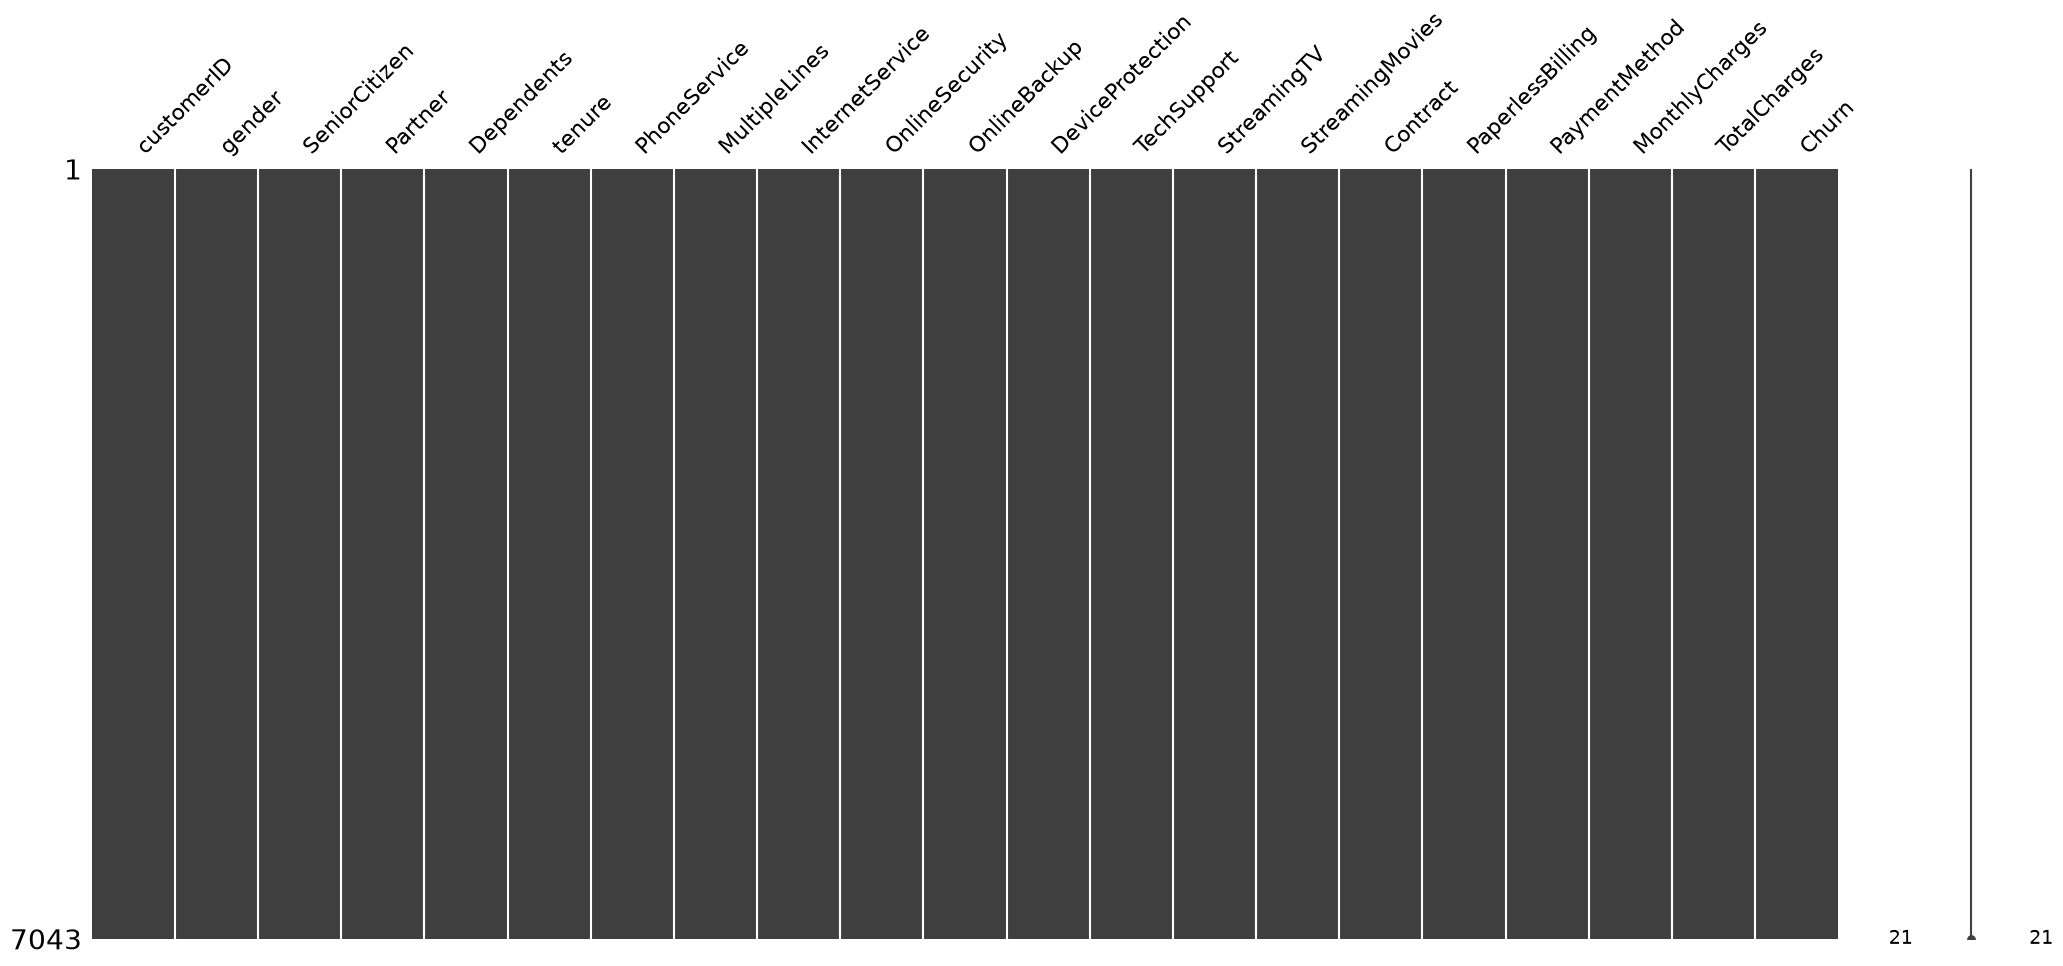

In [7]:
msno.matrix(df_raw)
plt.show()


Ngoài `TotalCharges`, `msno.matrix` và `isnull().sum()` không phát hiện thêm missing value nào — dataset
sạch ở mức "không có ô trống", vấn đề duy nhất là kiểu dữ liệu bị ẩn.


## 3. Outlier check trên numeric columns

Chỉ có 3 cột numeric thực sự: `tenure`, `MonthlyCharges`, `TotalCharges`.


In [8]:
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df_raw_numeric = df_raw.copy()
df_raw_numeric["TotalCharges"] = pd.to_numeric(df_raw_numeric["TotalCharges"], errors="coerce")
df_raw_numeric[numerical_cols].describe()


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


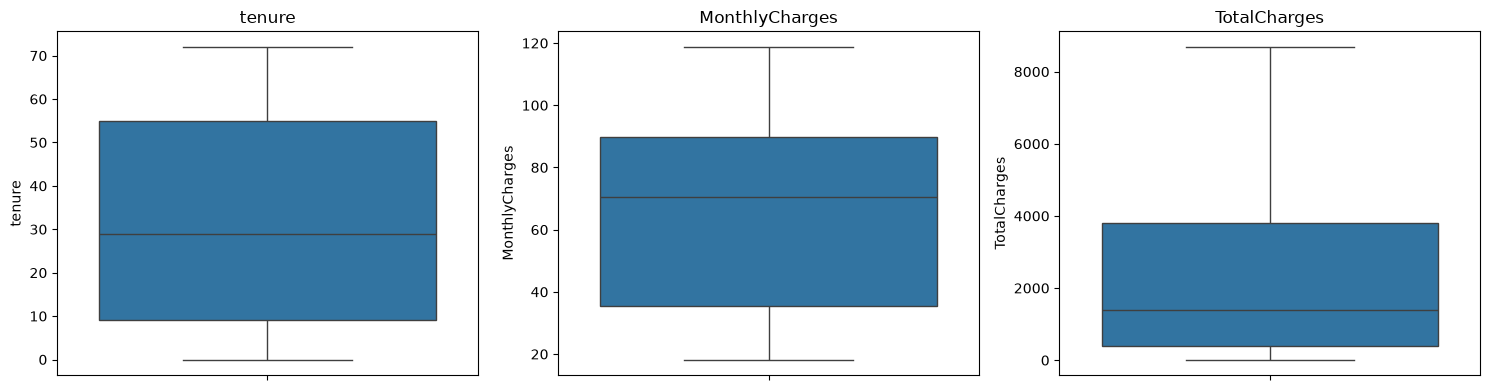

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(y=df_raw_numeric[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [10]:
def iqr_outlier_summary(series: pd.Series) -> dict:
    """Dem so outlier theo luat 1.5*IQR, chi de MO TA phan phoi, khong dung de loai bo du lieu."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_outlier = (series < lower) | (series > upper)
    return {
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "n_outliers": int(is_outlier.sum()),
        "pct_outliers": round(is_outlier.mean() * 100, 2),
    }


for col in numerical_cols:
    print(col, iqr_outlier_summary(df_raw_numeric[col].dropna()))


tenure {'lower_bound': -60.0, 'upper_bound': 124.0, 'n_outliers': 0, 'pct_outliers': np.float64(0.0)}
MonthlyCharges {'lower_bound': -46.02, 'upper_bound': 171.38, 'n_outliers': 0, 'pct_outliers': np.float64(0.0)}
TotalCharges {'lower_bound': -4688.48, 'upper_bound': 8884.67, 'n_outliers': 0, 'pct_outliers': np.float64(0.0)}


**Nhận xét outlier**: theo luật 1.5×IQR, **0% điểm dữ liệu** ở cả 3 cột bị coi là outlier — biên trên/dưới đủ rộng vì phân phối vốn đã lệch phải tự nhiên, không có giá trị vô lý về mặt
nghiệp vụ (âm, hoặc lớn bất thường so với billing thực tế). Phân phối lệch phải (right-skewed) là đặc trưng
tự nhiên của dữ liệu billing (khách gắn bó lâu/dùng nhiều dịch vụ sẽ có charges cao), **không phải lỗi đo
lường** — quyết định: không loại outlier ở bước clean chung; nếu model sau này nhạy với skew (ví dụ
Logistic Regression) sẽ xử lý bằng transform ở Pha 2, không xóa dữ liệu.


## 4. Apply cleaning (`src.data.clean`)

Áp dụng logic clean đã centralize — không viết lại fix ở đây, chỉ verify kết quả.


In [11]:
df = clean(df_raw)
print(f"Shape sau clean: {df.shape} (giam {df_raw.shape[0] - df.shape[0]} dong do loc tenure == 0)")
df.info()


Shape sau clean: (7032, 21) (giam 11 dong do loc tenure == 0)
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   str    
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str 

In [12]:
assert df.isnull().sum().sum() == 0, "Van con missing value sau khi clean"
assert df["customerID"].is_unique  # giu lai customerID de truy vet, khong dung lam feature
assert set(df["SeniorCitizen"].unique()) == {"No", "Yes"}
print("Da xac nhan: khong con missing value, customerID van unique (giu lai de truy vet, loai khoi feature set khi train), SeniorCitizen da chuan hoa No/Yes.")


Da xac nhan: khong con missing value, customerID van unique (giu lai de truy vet, loai khoi feature set khi train), SeniorCitizen da chuan hoa No/Yes.


## 5. Target distribution & class imbalance


In [13]:
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn"].value_counts(normalize=True).round(4)
print(churn_counts)
print(churn_rate)


Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     0.7342
Yes    0.2658
Name: proportion, dtype: float64


In [14]:
g_labels = ["Male", "Female"]
c_labels = ["No", "Yes"]

fig = make_subplots(rows=1, cols=2, specs=[[{"type": "domain"}, {"type": "domain"}]])
fig.add_trace(go.Pie(labels=g_labels, values=df["gender"].value_counts(), name="Gender"), 1, 1)
fig.add_trace(go.Pie(labels=c_labels, values=df["Churn"].value_counts(), name="Churn"), 1, 2)
fig.update_traces(hole=0.4, hoverinfo="label+percent+name", textfont_size=16)
fig.update_layout(
    title_text="Gender and Churn Distributions",
    annotations=[
        dict(text="Gender", x=0.16, y=0.5, font_size=20, showarrow=False),
        dict(text="Churn", x=0.84, y=0.5, font_size=20, showarrow=False),
    ],
)
fig.show()


Xác nhận lại con số đã dùng để quyết định primary metric ở `docs/docs.md`: **~73.5% No / ~26.5% Yes**.
Gender gần như cân bằng 50/50 — không phải nguồn gây imbalance.

> Đã bỏ biểu đồ donut lồng nhau (gender × churn) từng có trong bản notebook cũ vì nó dùng **số hard-code**
> (`[1869, 5163]`, `[939, 930, 2544, 2619]`) — sai lệch sau khi `clean()` loại 11 dòng `tenure == 0`, và là
> anti-pattern vì không tự cập nhật khi data đổi. Thay bằng các biểu đồ `px.histogram` bên dưới, luôn tính
> trực tiếp từ `df`.


## 6. Churn theo từng nhóm đặc trưng (bivariate EDA)


In [15]:
fig = px.histogram(
    df, x="Churn", color="Contract", barmode="group", title="<b>Customer contract distribution</b>"
)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()


In [16]:
fig = go.Figure(
    data=[go.Pie(labels=df["PaymentMethod"].value_counts().index, values=df["PaymentMethod"].value_counts(), hole=0.3)]
)
fig.update_layout(title_text="<b>Payment Method Distribution</b>")
fig.show()

fig = px.histogram(
    df, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>"
)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()


In [17]:
fig = px.histogram(
    df,
    x="Churn",
    color="InternetService",
    facet_col="gender",
    barmode="group",
    title="<b>Churn Distribution w.r.t. Internet Service and Gender</b>",
)
fig.update_layout(width=900, height=500)
fig.show()


In [18]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(
    df, x="Churn", color="Dependents", barmode="group", title="<b>Dependents distribution</b>", color_discrete_map=color_map
)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

color_map = {"Yes": "#FFA15A", "No": "#00CC96"}
fig = px.histogram(
    df, x="Churn", color="Partner", barmode="group", title="<b>Churn distribution w.r.t. Partners</b>", color_discrete_map=color_map
)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

color_map = {"Yes": "#00CC96", "No": "#B6E880"}
fig = px.histogram(
    df, x="Churn", color="SeniorCitizen", title="<b>Churn distribution w.r.t. Senior Citizen</b>", color_discrete_map=color_map
)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()


In [19]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(
    df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Churn w.r.t Online Security</b>", color_discrete_map=color_map
)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

color_map = {"Yes": "#FFA15A", "No": "#00CC96"}
fig = px.histogram(
    df, x="Churn", color="PaperlessBilling", title="<b>Churn distribution w.r.t. Paperless Billing</b>", color_discrete_map=color_map
)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

fig = px.histogram(df, x="Churn", color="TechSupport", barmode="group", title="<b>Churn distribution w.r.t. TechSupport</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

color_map = {"Yes": "#00CC96", "No": "#B6E880"}
fig = px.histogram(
    df, x="Churn", color="PhoneService", title="<b>Churn distribution w.r.t. Phone Service</b>", color_discrete_map=color_map
)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()


## 7. Numeric features vs Churn


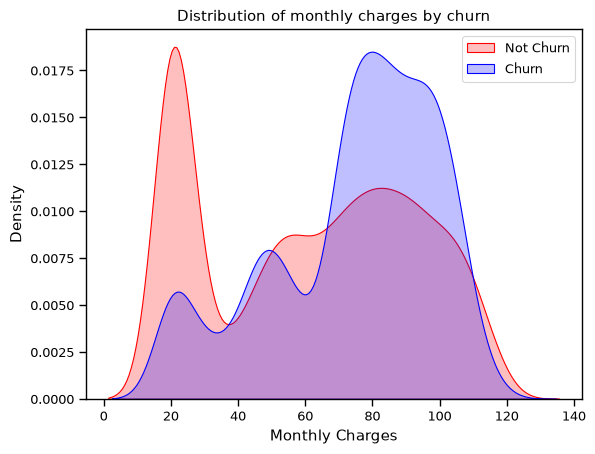

In [20]:
sns.set_context("paper", font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[df["Churn"] == "No"], color="Red", fill=True)
ax = sns.kdeplot(df.MonthlyCharges[df["Churn"] == "Yes"], ax=ax, color="Blue", fill=True)
ax.legend(["Not Churn", "Churn"], loc="upper right")
ax.set_ylabel("Density")
ax.set_xlabel("Monthly Charges")
ax.set_title("Distribution of monthly charges by churn")
plt.show()


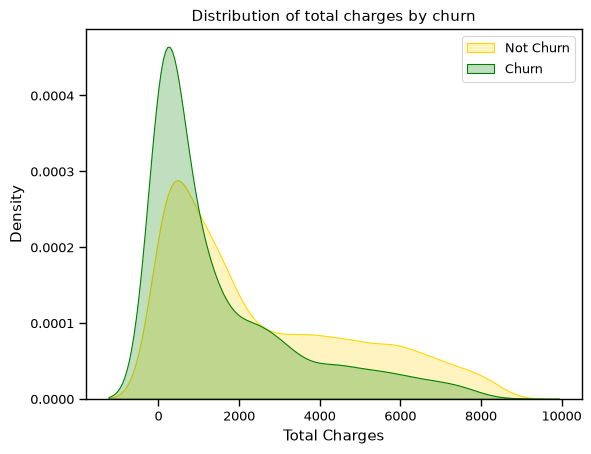

In [21]:
ax = sns.kdeplot(df.TotalCharges[df["Churn"] == "No"], color="Gold", fill=True)
ax = sns.kdeplot(df.TotalCharges[df["Churn"] == "Yes"], ax=ax, color="Green", fill=True)
ax.legend(["Not Churn", "Churn"], loc="upper right")
ax.set_ylabel("Density")
ax.set_xlabel("Total Charges")
ax.set_title("Distribution of total charges by churn")
plt.show()


In [22]:
fig = px.box(df, x="Churn", y="tenure")
fig.update_yaxes(title_text="Tenure (Months)")
fig.update_xaxes(title_text="Churn")
fig.update_layout(
    autosize=True, width=750, height=600, title_font=dict(size=25, family="Courier"), title="<b>Tenure vs Churn</b>"
)
fig.show()


**Nhận xét nhanh** (sẽ định lượng lại kỹ hơn bằng feature importance ở Pha 3, đây chỉ là quan sát trực quan
để định hướng): khách churn có xu hướng `tenure` thấp, `MonthlyCharges` cao, `Contract` month-to-month,
`PaymentMethod` electronic check, và thiếu các dịch vụ bảo vệ (`OnlineSecurity`, `TechSupport`) — hợp lý về
mặt nghiệp vụ (khách mới, cam kết ngắn hạn, ít gắn bó dịch vụ → dễ rời đi).


## 8. Correlation overview (caveat)

`pd.factorize` áp thứ tự **tùy ý** lên các cột categorical nominal (không có thứ tự thật) để tính correlation
— hữu ích để quét nhanh xem cột nào "có vẻ" liên quan đến `Churn`, nhưng **không được diễn giải giá trị
correlation của các cột categorical như một con số ý nghĩa thống kê chặt chẽ**, vì thứ tự factorize là ngẫu
nhiên. Chỉ dùng bước này để định hướng, không dùng để chọn/loại feature chính thức — việc đó thuộc Pha 3
(feature importance từ model thật).


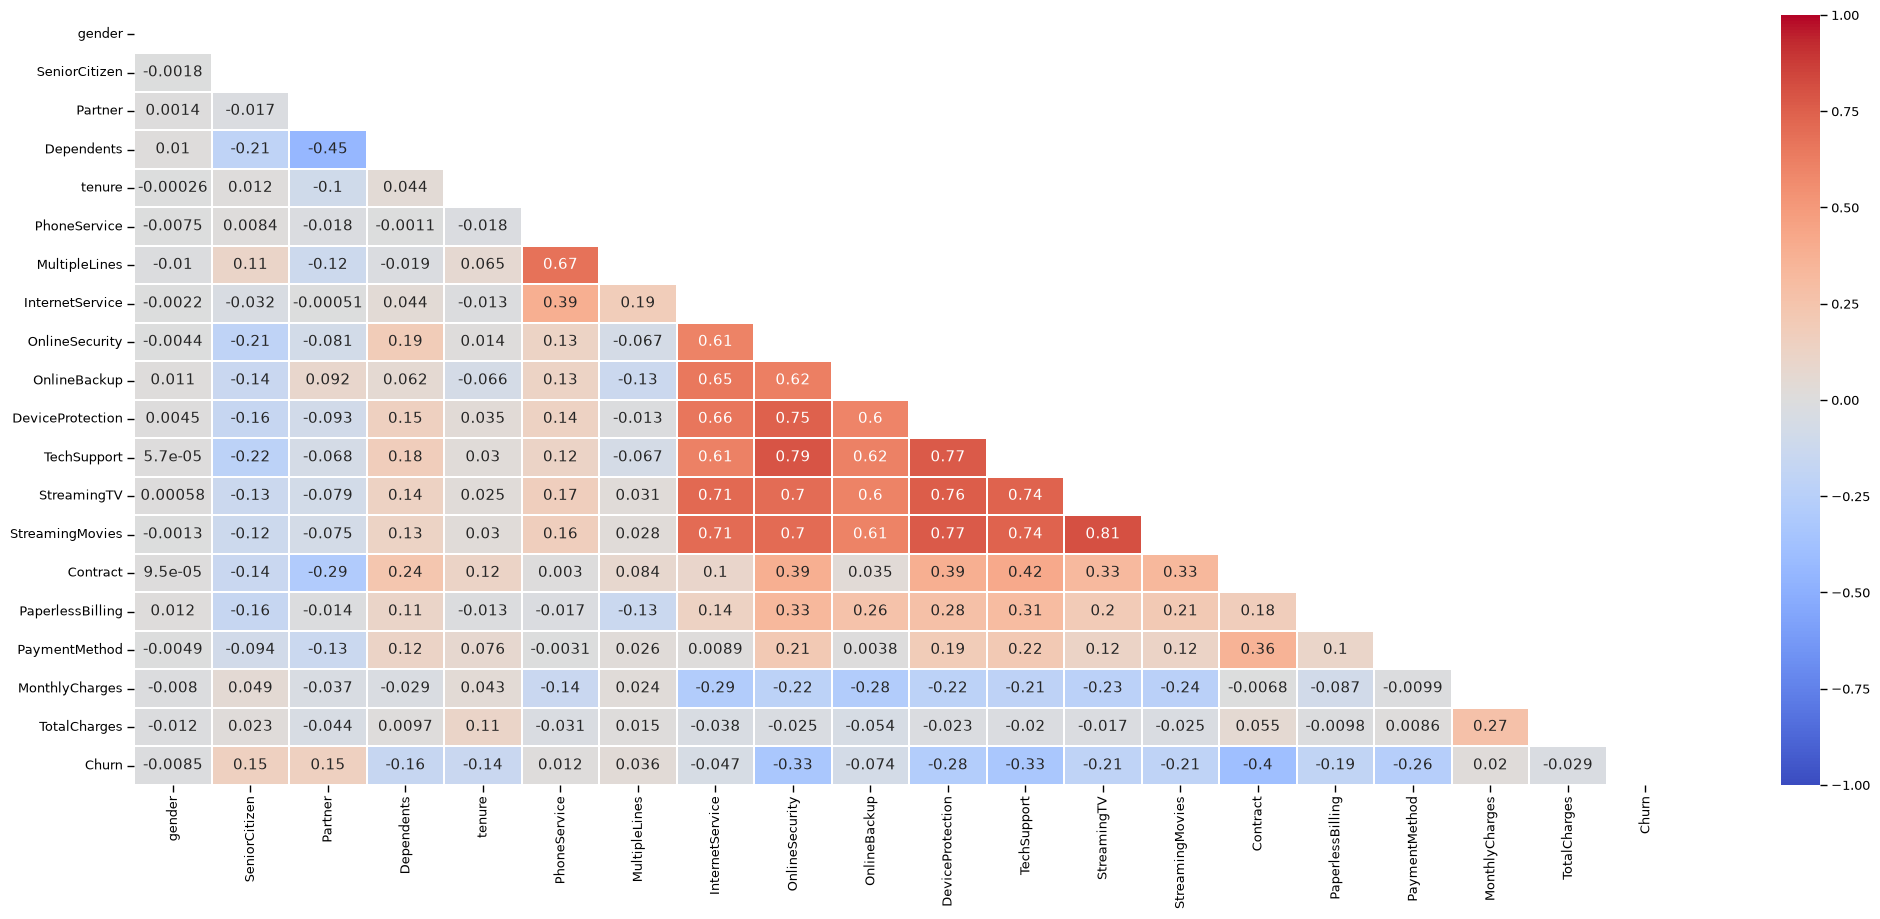

In [23]:
plt.figure(figsize=(25, 10))
corr = df.drop(columns=["customerID"]).apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=0.2, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()


## 9. Tổng kết Pha 1 & bàn giao sang Pha 2

- Data hygiene issues đã xác định và fix trong `src/data/loader.py`: `TotalCharges` object→numeric,
  loại 11 dòng `tenure == 0`, chuẩn hóa `SeniorCitizen`. `customerID` được GIỮ LẠI trong dataframe (định danh để truy vết ở Pha 4/error analysis) nhưng phải loại khỏi feature set khi train — mỗi task tự loại tường minh, không dựa vào việc loader() đã xóa sẵn.
- Không có missing value nào khác ngoài trường hợp trên; outlier ở numeric columns là tín hiệu hợp lệ, không
  phải lỗi — không loại bỏ.
- Target imbalance 73.5/26.5 → quyết định primary metric (PR-AUC + F2) đã chốt tại `docs/docs.md`.
- Bước tiếp theo (`02_data_preparation.ipynb`): thiết kế validation strategy (Stratified K-Fold — hợp lệ vì
  mỗi khách hàng chỉ có 1 dòng, không có time dimension) và preprocessing pipeline numeric/categorical.
